# Multiplayer: Vergleich verschiedener Spielerkonfigurationen

Systematischer Vergleich unterschiedlicher Experten/Anfänger-Verhältnisse.

In [1]:
%pip install numpy pymoo pandas matplotlib seaborn tqdm --quiet


[notice] A new release of pip is available: 24.3.1 -> 25.3
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import random
import time
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import json

from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.operators.crossover.sbx import SBX
from pymoo.operators.mutation.pm import PM
from pymoo.operators.sampling.rnd import FloatRandomSampling
from pymoo.termination import get_termination
from pymoo.optimize import minimize
from pymoo.indicators.hv import HV
from pymoo.util.nds.non_dominated_sorting import NonDominatedSorting

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 10)
plt.rcParams['font.size'] = 20
plt.rcParams['axes.titlesize'] = 26
plt.rcParams['axes.labelsize'] = 20
plt.rcParams['xtick.labelsize'] = 20
plt.rcParams['ytick.labelsize'] = 20
plt.rcParams['legend.fontsize'] = 16

In [3]:
from simulation import (
    TopTrumpsMultiplayerSimulation,
    TopTrumpsMultiplayerBalancing,
    evaluate_multiplayer_deck_detailed
)

In [4]:
SEED = 42
np.random.seed(SEED)
random.seed(SEED)

In [5]:
RESULTS_DIR = Path('results/multiplayer_configs')
PLOTS_DIR = Path('plots/multiplayer_configs')
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

## Konfigurationen

In [6]:
# All configurations with at least 1 Expert, 2-4 players
# NOTE: Fairness is measured for the FOCUS EXPERT (first expert) only!
CONFIGURATIONS = {
    # 2 Players
    '2P_1E_1A': {'strategies': ['p4', 'p0'], 'K': 24, 'description': '2P: 1E vs 1A'},
    '2P_2E_0A': {'strategies': ['p4', 'p4'], 'K': 24, 'description': '2P: 2E vs 0A (E vs E)'},
    # 3 Players
    '3P_1E_2A': {'strategies': ['p4', 'p0', 'p0'], 'K': 24, 'description': '3P: 1E vs 2A'},
    '3P_2E_1A': {'strategies': ['p4', 'p4', 'p0'], 'K': 24, 'description': '3P: 2E vs 1A'},
    '3P_3E_0A': {'strategies': ['p4', 'p4', 'p4'], 'K': 24, 'description': '3P: 3E vs 0A (all E)'},
    # 4 Players
    '4P_1E_3A': {'strategies': ['p4', 'p0', 'p0', 'p0'], 'K': 24, 'description': '4P: 1E vs 3A'},
    '4P_2E_2A': {'strategies': ['p4', 'p4', 'p0', 'p0'], 'K': 24, 'description': '4P: 2E vs 2A'},
    '4P_3E_1A': {'strategies': ['p4', 'p4', 'p4', 'p0'], 'K': 24, 'description': '4P: 3E vs 1A'},
    '4P_4E_0A': {'strategies': ['p4', 'p4', 'p4', 'p4'], 'K': 24, 'description': '4P: 4E vs 0A (all E)'},
}

print('Configurations (Fairness = Focus Expert Win Rate):')
print('=' * 50)
for name, cfg in CONFIGURATIONS.items():
    n_experts = cfg['strategies'].count('p4')
    print(f"{name}: {cfg['description']} ({n_experts}E)")

Configurations (Fairness = Focus Expert Win Rate):
2P_1E_1A: 2P: 1E vs 1A (1E)
2P_2E_0A: 2P: 2E vs 0A (E vs E) (2E)
3P_1E_2A: 3P: 1E vs 2A (1E)
3P_2E_1A: 3P: 2E vs 1A (2E)
3P_3E_0A: 3P: 3E vs 0A (all E) (3E)
4P_1E_3A: 4P: 1E vs 3A (1E)
4P_2E_2A: 4P: 2E vs 2A (2E)
4P_3E_1A: 4P: 3E vs 1A (3E)
4P_4E_0A: 4P: 4E vs 0A (all E) (4E)


## Parameter

In [7]:
L = 4
XL, XU = 1.0, 10.0
POP_SIZE = 60
N_GEN = 100
R_EVAL_FAST = 1000   # Simulations during optimization
R_EVAL_FINAL = 1500  # Simulations for validation

print(f'Pop: {POP_SIZE}, Gen: {N_GEN}, R_fast: {R_EVAL_FAST}, R_final: {R_EVAL_FINAL}')

Pop: 60, Gen: 100, R_fast: 1000, R_final: 1500


## Optimierung

In [8]:
all_results = {}

for config_name, config in CONFIGURATIONS.items():
    print(f'\n=== {config_name}: {config["description"]} ===')
    
    np.random.seed(SEED)
    random.seed(SEED)
    
    sim = TopTrumpsMultiplayerSimulation(
        num_cards=config['K'],
        num_categories=L,
        player_strategies=config['strategies']
    )
    
    problem = TopTrumpsMultiplayerBalancing(
        sim_instance=sim, n_simulations=R_EVAL_FAST, xl=XL, xu=XU
    )
    
    algorithm = NSGA2(
        pop_size=POP_SIZE,
        sampling=FloatRandomSampling(),
        crossover=SBX(prob=0.9, eta=15),
        mutation=PM(eta=20),
        eliminate_duplicates=True
    )
    
    start_time = time.time()
    res = minimize(problem, algorithm, get_termination('n_gen', N_GEN), seed=SEED, verbose=False)
    opt_time = time.time() - start_time
    print(f'  Optimierung: {opt_time:.1f}s, {len(res.F)} Loesungen')
    
    validated = [evaluate_multiplayer_deck_detailed(sim, x, R=R_EVAL_FINAL) for x in res.X]
    validated_df = pd.DataFrame(validated)
    
    # Non-Dominated Sorting after validation (using Focus Expert Win Rate)
    F_val = np.column_stack([-validated_df['focus_expert_win_rate'].values, -validated_df['trick_changes'].values])
    nds = NonDominatedSorting()
    fronts = nds.do(F_val)
    non_dominated_idx = fronts[0]
    n_before = len(validated_df)
    validated_df = validated_df.iloc[non_dominated_idx].reset_index(drop=True)
    F_val = F_val[non_dominated_idx]
    
    hv = HV(ref_point=np.array([0.0, 0.0]))(F_val)
    
    all_results[config_name] = {
        'config': config, 'validated_df': validated_df, 'hypervolume': hv,
        'optimization_time': opt_time,
        'stats': {
            'focus_expert_win_rate_mean': validated_df['focus_expert_win_rate'].mean(),
            'focus_expert_win_rate_min': validated_df['focus_expert_win_rate'].min(),
            'focus_expert_win_rate_max': validated_df['focus_expert_win_rate'].max(),
            'any_expert_win_rate_mean': validated_df['any_expert_win_rate'].mean(),
            'num_experts': validated_df['num_experts'].iloc[0],
            'trick_changes_mean': validated_df['trick_changes'].mean(),
            'tie_rate_mean': validated_df['tie_rate'].mean(),
            'n_solutions': len(validated_df)
        }
    }
    print(f'  NDS: {n_before} -> {len(validated_df)}, HV: {hv:.4f}, Focus E WR: {validated_df["focus_expert_win_rate"].mean():.1%}')

print('\nAlle Optimierungen abgeschlossen!')


=== 2P_1E_1A: 2P: 1E vs 1A ===
  Optimierung: 193.1s, 21 Loesungen
  NDS: 21 -> 11, HV: 3.6032, Focus E WR: 76.7%

=== 2P_2E_0A: 2P: 2E vs 0A (E vs E) ===
  Optimierung: 265.4s, 8 Loesungen
  NDS: 8 -> 2, HV: 3.0617, Focus E WR: 60.2%

=== 3P_1E_2A: 3P: 1E vs 2A ===
  Optimierung: 130.9s, 26 Loesungen
  NDS: 26 -> 9, HV: 3.1653, Focus E WR: 62.3%

=== 3P_2E_1A: 3P: 2E vs 1A ===
  Optimierung: 165.6s, 10 Loesungen
  NDS: 10 -> 3, HV: 2.1199, Focus E WR: 45.2%

=== 3P_3E_0A: 3P: 3E vs 0A (all E) ===
  Optimierung: 200.4s, 9 Loesungen
  NDS: 9 -> 6, HV: 1.8468, Focus E WR: 40.6%

=== 4P_1E_3A: 4P: 1E vs 3A ===
  Optimierung: 104.6s, 9 Loesungen
  NDS: 9 -> 4, HV: 1.8507, Focus E WR: 44.6%

=== 4P_2E_2A: 4P: 2E vs 2A ===
  Optimierung: 127.8s, 8 Loesungen
  NDS: 8 -> 5, HV: 1.7981, Focus E WR: 40.7%

=== 4P_3E_1A: 4P: 3E vs 1A ===
  Optimierung: 147.6s, 8 Loesungen
  NDS: 8 -> 3, HV: 1.4105, Focus E WR: 34.9%

=== 4P_4E_0A: 4P: 4E vs 0A (all E) ===
  Optimierung: 170.3s, 8 Loesungen
  NDS

## Ergebnis-Tabelle

In [9]:
summary_data = []
for name, r in all_results.items():
    n_players = len(r['config']['strategies'])
    summary_data.append({
        'Config': name,
        'Players': n_players,
        'Experts': r['stats']['num_experts'],
        'Focus E WR': f"{r['stats']['focus_expert_win_rate_mean']:.1%}",
        'Any E WR': f"{r['stats']['any_expert_win_rate_mean']:.1%}",
        'Trick Ch.': f"{r['stats']['trick_changes_mean']:.2f}",
        'Tie Rate': f"{r['stats']['tie_rate_mean']:.1%}",
        'HV': f"{r['hypervolume']:.3f}",
        'Skill Adv.': f"{r['stats']['focus_expert_win_rate_mean'] / (1/n_players):.2f}x"
    })
print('Focus E WR = Win Rate of the Focus Expert (Player 0)')
print('Any E WR = Win Rate of any Expert (for comparison)')
print('Skill Adv. = Focus Expert WR / Random Chance')
pd.DataFrame(summary_data)

Focus E WR = Win Rate of the Focus Expert (Player 0)
Any E WR = Win Rate of any Expert (for comparison)
Skill Adv. = Focus Expert WR / Random Chance


,Config,Players,Experts,Focus E WR,Any E WR,Trick Ch.,Tie Rate,HV,Skill Adv.
0,2P_1E_1A,2,1,76.7%,76.7%,3.99,14.2%,3.603,1.53x
1,2P_2E_0A,2,2,60.2%,100.0%,4.96,18.0%,3.062,1.20x
2,3P_1E_2A,3,1,62.3%,62.3%,4.50,22.0%,3.165,1.87x
3,3P_2E_1A,3,2,45.2%,80.9%,4.52,24.2%,2.120,1.36x
4,3P_3E_0A,3,3,40.6%,100.0%,4.25,22.4%,1.847,1.22x
5,4P_1E_3A,4,1,44.6%,44.6%,3.93,31.9%,1.851,1.79x
6,4P_2E_2A,4,2,40.7%,71.3%,4.04,32.0%,1.798,1.63x
7,4P_3E_1A,4,3,34.9%,83.4%,3.78,29.5%,1.410,1.40x
8,4P_4E_0A,4,4,37.9%,100.0%,4.09,33.0%,1.549,1.51x


## Pareto-Fronts Plot

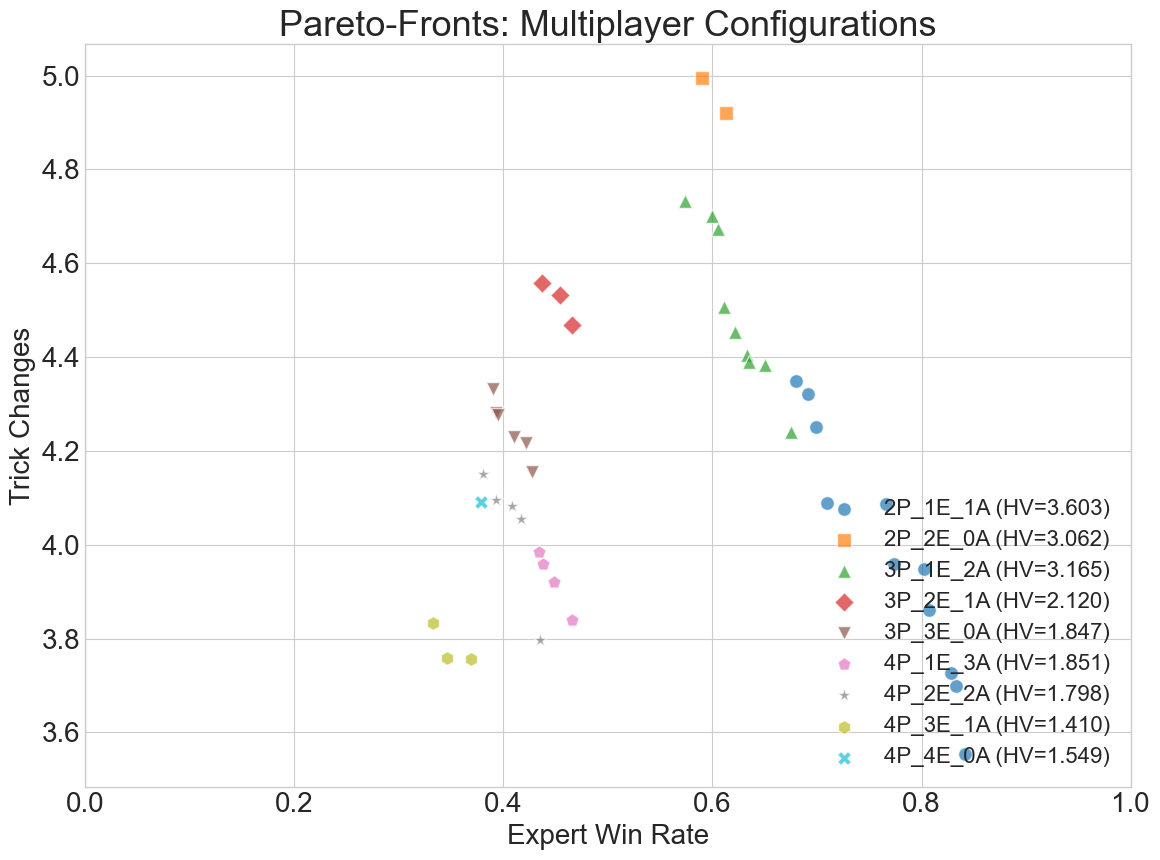

In [14]:
fig, ax = plt.subplots(figsize=(12, 9))
colors = plt.cm.tab10(np.linspace(0, 1, len(all_results)))
markers = ['o', 's', '^', 'D', 'v', 'p', '*', 'h', 'X']  # 9 markers for 9 configs

for i, (name, r) in enumerate(all_results.items()):
    df = r['validated_df']
    ax.scatter(df['focus_expert_win_rate'], df['trick_changes'], c=[colors[i]], marker=markers[i % len(markers)],
               s=100, alpha=0.7, edgecolors='white', label=f"{name} (HV={r['hypervolume']:.3f})")

ax.set_xlabel('Expert Win Rate')
ax.set_ylabel('Trick Changes')
ax.set_title('Pareto-Fronts: Multiplayer Configurations')
ax.legend(loc='lower right')
ax.set_xlim(0, 1)
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'pareto_fronts_comparison.svg', format='svg')
plt.show()

## Boxplots

/var/folders/9l/s6j5yq4s12j6wvms4084h50h0000gn/T/ipykernel_6702/3483596170.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot([all_results[n]['validated_df']['focus_expert_win_rate'] for n in names], labels=names, flierprops={"marker": "x", "markersize": 5, "markeredgecolor": "black", "markeredgewidth": 1})
/var/folders/9l/s6j5yq4s12j6wvms4084h50h0000gn/T/ipykernel_6702/3483596170.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([all_results[n]['validated_df']['trick_changes'] for n in names], labels=names, flierprops={"marker": "x", "markersize": 5, "markeredgecolor": "black", "markeredgewidth": 1})
/var/folders/9l/s6j5yq4s12j6wvms4084h50h0000gn/T/ipykernel_6702/3483596170.py:12: MatplotlibDeprecationWar

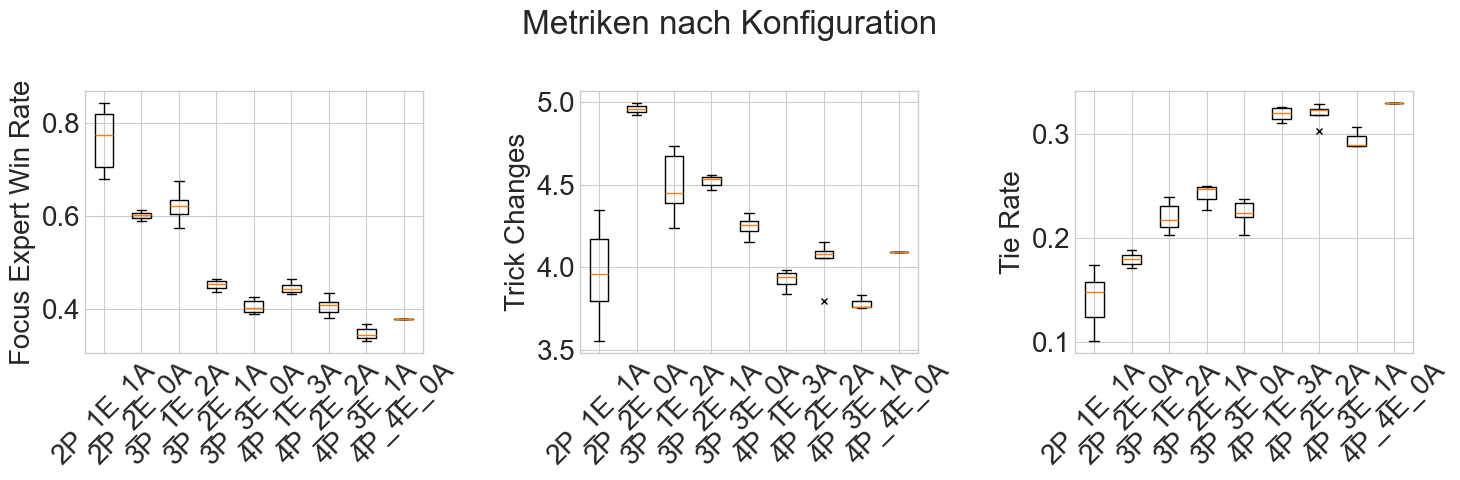

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
names = list(all_results.keys())

axes[0].boxplot([all_results[n]['validated_df']['focus_expert_win_rate'] for n in names], labels=names, flierprops={"marker": "x", "markersize": 5, "markeredgecolor": "black", "markeredgewidth": 1})
axes[0].set_ylabel('Focus Expert Win Rate')
axes[0].tick_params(axis='x', rotation=45)

axes[1].boxplot([all_results[n]['validated_df']['trick_changes'] for n in names], labels=names, flierprops={"marker": "x", "markersize": 5, "markeredgecolor": "black", "markeredgewidth": 1})
axes[1].set_ylabel('Trick Changes')
axes[1].tick_params(axis='x', rotation=45)

axes[2].boxplot([all_results[n]['validated_df']['tie_rate'] for n in names], labels=names, flierprops={"marker": "x", "markersize": 5, "markeredgecolor": "black", "markeredgewidth": 1})
axes[2].set_ylabel('Tie Rate')
axes[2].tick_params(axis='x', rotation=45)

plt.suptitle('Metriken nach Konfiguration')
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'metrics_boxplots.svg', format='svg')
plt.show()

## Ergebnisse speichern

In [12]:
def convert_to_native(obj):
    """Convert numpy types to native Python types for JSON serialization."""
    if isinstance(obj, dict):
        return {k: convert_to_native(v) for k, v in obj.items()}
    elif isinstance(obj, (list, tuple)):
        return [convert_to_native(v) for v in obj]
    elif isinstance(obj, (np.integer, np.int64)):
        return int(obj)
    elif isinstance(obj, (np.floating, np.float64)):
        return float(obj)
    elif isinstance(obj, np.ndarray):
        return obj.tolist()
    return obj

export = {name: convert_to_native({'config': r['config'], 'hypervolume': r['hypervolume'], 'stats': r['stats']}) for name, r in all_results.items()}
with open(RESULTS_DIR / 'configuration_comparison.json', 'w') as f:
    json.dump(export, f, indent=2)
print('Results saved to', RESULTS_DIR)

Results saved to results/multiplayer_configs


## Fazit

In [13]:
print('=== FAZIT ===')
for name, r in all_results.items():
    n = len(r['config']['strategies'])
    n_experts = r['stats']['num_experts']
    adv = r['stats']['focus_expert_win_rate_mean'] / (1/n)
    print(f"{name} ({n_experts}E): Skill Advantage = {adv:.2f}x (Random = {1/n:.1%}, Focus Expert = {r['stats']['focus_expert_win_rate_mean']:.1%})")

=== FAZIT ===
2P_1E_1A (1E): Skill Advantage = 1.53x (Random = 50.0%, Focus Expert = 76.7%)
2P_2E_0A (2E): Skill Advantage = 1.20x (Random = 50.0%, Focus Expert = 60.2%)
3P_1E_2A (1E): Skill Advantage = 1.87x (Random = 33.3%, Focus Expert = 62.3%)
3P_2E_1A (2E): Skill Advantage = 1.36x (Random = 33.3%, Focus Expert = 45.2%)
3P_3E_0A (3E): Skill Advantage = 1.22x (Random = 33.3%, Focus Expert = 40.6%)
4P_1E_3A (1E): Skill Advantage = 1.79x (Random = 25.0%, Focus Expert = 44.6%)
4P_2E_2A (2E): Skill Advantage = 1.63x (Random = 25.0%, Focus Expert = 40.7%)
4P_3E_1A (3E): Skill Advantage = 1.40x (Random = 25.0%, Focus Expert = 34.9%)
4P_4E_0A (4E): Skill Advantage = 1.51x (Random = 25.0%, Focus Expert = 37.9%)
